/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Adjusted ARIMA Model Performance:
Mean Squared Error (MSE): 15.596304087534769
Root Mean Squared Error (RMSE): 3.9492156294047516
Mean Absolute Error (MAE): 3.248412503595523


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



SARIMAX Model Performance:
Mean Squared Error (MSE): 3.4185899061235627
Root Mean Squared Error (RMSE): 1.8489429158639707
Mean Absolute Error (MAE): 1.4620291176646039


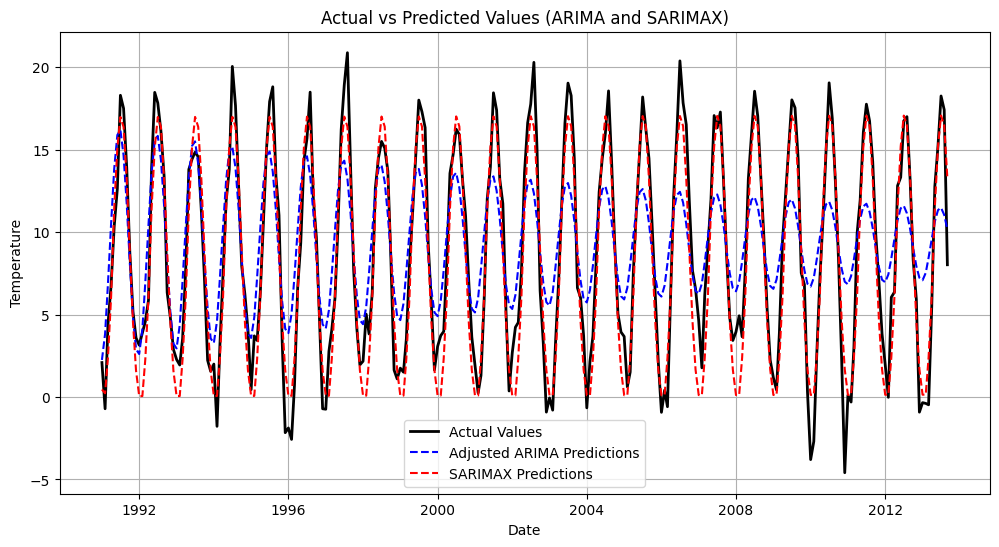


Comparison file saved to actual_vs_adjusted_arima_sarimax.csv


In [7]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt


file_path = 'filtered_timeseries_file.csv'
time_series_data = pd.read_csv(file_path)

time_series_data['dt'] = pd.to_datetime(time_series_data['dt'], format='%d/%m/%Y')
time_series_data.set_index('dt', inplace=True)

temperature_series = time_series_data['AverageTemperature']

split_point = int(len(temperature_series) * 0.8)
train_data = temperature_series[:split_point]
test_data = temperature_series[split_point:]

# --- Adjusted ARIMA Model ---
adjusted_arima_model = ARIMA(train_data, order=(2, 1, 2))
adjusted_arima_fit = adjusted_arima_model.fit()

adjusted_arima_forecast = adjusted_arima_fit.forecast(steps=len(test_data))

adjusted_arima_mse = mean_squared_error(test_data, adjusted_arima_forecast)
adjusted_arima_rmse = sqrt(adjusted_arima_mse)
adjusted_arima_mae = mean_absolute_error(test_data, adjusted_arima_forecast)

print("Adjusted ARIMA Model Performance:")
print(f"Mean Squared Error (MSE): {adjusted_arima_mse}")
print(f"Root Mean Squared Error (RMSE): {adjusted_arima_rmse}")
print(f"Mean Absolute Error (MAE): {adjusted_arima_mae}")

# --- SARIMAX Model ---
sarimax_model = SARIMAX(
    train_data,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_forecast = sarimax_fit.forecast(steps=len(test_data))

sarimax_mse = mean_squared_error(test_data, sarimax_forecast)
sarimax_rmse = sqrt(sarimax_mse)
sarimax_mae = mean_absolute_error(test_data, sarimax_forecast)

print("\nSARIMAX Model Performance:")
print(f"Mean Squared Error (MSE): {sarimax_mse}")
print(f"Root Mean Squared Error (RMSE): {sarimax_rmse}")
print(f"Mean Absolute Error (MAE): {sarimax_mae}")

plt.figure(figsize=(12, 6))

plt.plot(test_data.index, test_data, label='Actual Values', color='black', linewidth=2)

plt.plot(test_data.index, adjusted_arima_forecast, label='Adjusted ARIMA Predictions', linestyle='--', color='blue')

plt.plot(test_data.index, sarimax_forecast, label='SARIMAX Predictions', linestyle='--', color='red')

plt.title('Actual vs Predicted Values (ARIMA and SARIMAX)')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

comparison_df = pd.DataFrame({
    'Actual': test_data,
    'Adjusted_ARIMA_Predicted': adjusted_arima_forecast,
    'SARIMAX_Predicted': sarimax_forecast
})

output_file_path = 'actual_vs_adjusted_arima_sarimax.csv'
comparison_df.to_csv(output_file_path, index=True)
print(f"\nComparison file saved to {output_file_path}")

